In [123]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.datasets import cifar10
from tensorflow.keras import layers, models
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

Import i podział danych

In [129]:
# Wczytanie danych
(x_train_raw, y_train_raw), (x_test_raw, y_test_raw) = cifar10.load_data()

# Połączenie danych, aby móc uzyskać podział 60/20/20
x_all = np.concatenate([x_train_raw, x_test_raw], axis=0)
y_all = np.concatenate([y_train_raw, y_test_raw], axis=0)

print(x_all.shape)
print(y_all.shape)

(60000, 32, 32, 3)
(60000, 1)


In [130]:
# Normalizacja: 0–255 -> 0–1
x_all = x_all.astype("float32") / 255.0

# Najpierw wydzielamy 20% na test
x_temp, x_test, y_temp, y_test = train_test_split(
    x_all,
    y_all,
    test_size=0.20,
    random_state=42,
    stratify=y_all
)

# Z pozostałych 80% wydzielamy 25%, czyli 20% całości, na walidację
x_train, x_val, y_train, y_val = train_test_split(
    x_temp,
    y_temp,
    test_size=0.25,
    random_state=42,
    stratify=y_temp
)

print("Train:", x_train.shape, y_train.shape)
print("Validation:", x_val.shape, y_val.shape)
print("Test:", x_test.shape, y_test.shape)

Train: (36000, 32, 32, 3) (36000, 1)
Validation: (12000, 32, 32, 3) (12000, 1)
Test: (12000, 32, 32, 3) (12000, 1)


In [131]:
class_names = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck"
]

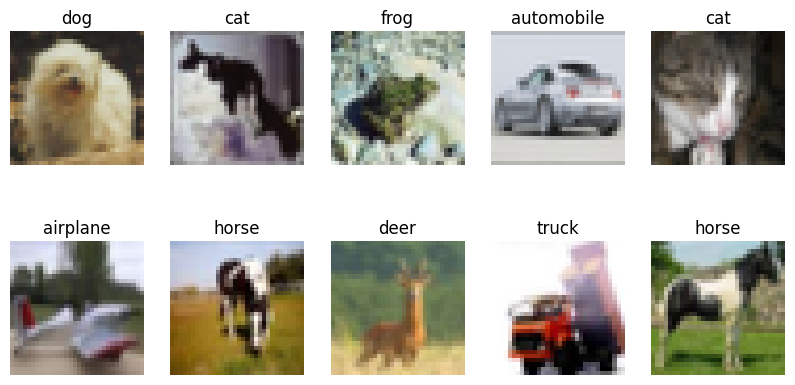

In [279]:
plt.figure(figsize=(10, 5), facecolor="white")

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis("off")

plt.show()

Augmentacja danych

In [289]:
data_augmentation = tf.keras.Sequential([
    layers.Input(shape=(32, 32, 3)),
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
])

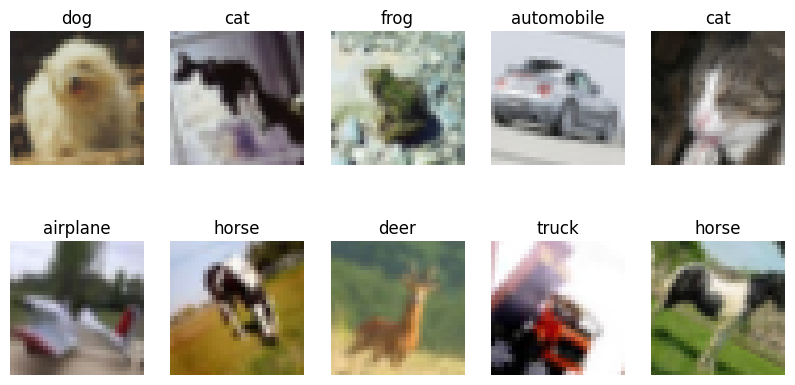

In [304]:
plt.figure(figsize=(10, 5), facecolor="white")

for i in range(10):
    img = x_train[i:i+1]   # robi batch: (1, 32, 32, 3)

    aug_img = data_augmentation(img, training=True)
    aug_img = aug_img[0]   # z powrotem: (32, 32, 3)

    plt.subplot(2, 5, i + 1)
    plt.imshow(aug_img)
    plt.title(class_names[y_train[i][0]])
    plt.axis("off")

plt.show()

MODEL 1

In [306]:
def build_model_1():
    model = models.Sequential([
        layers.Input(shape=(32, 32, 3)),

        data_augmentation,

        layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
        layers.MaxPooling2D((2, 2)),

        layers.Flatten(),
        layers.Dense(128, activation="relu"),
        layers.Dropout(0.3),

        layers.Dense(10, activation="softmax")
    ])

    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

In [307]:
model_1 = build_model_1()
model_1.summary()

Model: "sequential_14"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_13 (Sequential)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       524,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 545,098 (2.08 MB)

 Trainable params: 545,098 (2.08 MB)

 Non-trainable params: 0 (0.00 B)

MODEL 2

In [310]:
def build_model_2():
    model = models.Sequential([
        layers.Input(shape=(32, 32, 3)),

        data_augmentation,

        layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
        layers.BatchNormalization(),
        layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),

        layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
        layers.BatchNormalization(),
        layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.3),

        layers.Conv2D(128, (3, 3), activation="relu", padding="same"),
        layers.BatchNormalization(),
        layers.GlobalAveragePooling2D(),

        layers.Dense(128, activation="relu"),
        layers.Dropout(0.4),

        layers.Dense(10, activation="softmax")
    ])

    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

In [311]:
model_2 = build_model_2()
model_2.summary()

Model: "sequential_16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_13 (Sequential)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 158,506 (619.16 KB)

 Trainable params: 157,866 (616.66 KB)

 Non-trainable params: 640 (2.50 KB)

Trenowanie modeli

In [317]:
EPOCHS = 15
BATCH_SIZE = 64

In [318]:
history_1 = model_1.fit(
    x_train,
    y_train,
    validation_data=(x_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE
)

history_2 = model_2.fit(
    x_train,
    y_train,
    validation_data=(x_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE
)

Epoch 1/15
563/563 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.3724 - loss: 1.7265 - val_accuracy: 0.5107 - val_loss: 1.3722
Epoch 2/15
563/563 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.4773 - loss: 1.4557 - val_accuracy: 0.5615 - val_loss: 1.2490
Epoch 3/15
563/563 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.5191 - loss: 1.3454 - val_accuracy: 0.6046 - val_loss: 1.1212
Epoch 4/15
563/563 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.5465 - loss: 1.2737 - val_accuracy: 0.6025 - val_loss: 1.1201
Epoch 5/15
563/563 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.5624 - loss: 1.2293 - val_accuracy: 0.6145 - val_loss: 1.0704
Epoch 6/15
563/563 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.5794 - loss: 1.1903 - val_accuracy: 0.6348 - val_loss: 1.0304
Epoch 7/15
563/563 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.5848 - loss: 1.1662 - val_accuracy: 0.6225 - val_loss: 1.0850
Epoch 8/15
563/563 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.5974 - loss: 1.1366 - val_accuracy: 0.

Wykresy 'loss train/validation vs epochs' i 'accuracy vs epochs'

In [364]:
def plot_losses_side_by_side(history_1, history_2):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

    # Model 1
    axes[0].plot(history_1.history["loss"], label="Train loss")
    axes[0].plot(history_1.history["val_loss"], label="Validation loss")
    axes[0].set_title("Model 1 - Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].legend()
    axes[0].grid(True)

    # Model 2
    axes[1].plot(history_2.history["loss"], label="Train loss")
    axes[1].plot(history_2.history["val_loss"], label="Validation loss")
    axes[1].set_title("Model 2 - Loss")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Loss")
    axes[1].legend()
    axes[1].grid(True)

    plt.tight_layout()
    plt.show()

def plot_accuracies_side_by_side(history_1, history_2):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

    # Model 1
    axes[0].plot(history_1.history["accuracy"], label="Train accuracy")
    axes[0].plot(history_1.history["val_accuracy"], label="Validation accuracy")
    axes[0].set_title("Model 1 - accuracy")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("accuracy")
    axes[0].legend()
    axes[0].grid(True)

    # Model 2
    axes[1].plot(history_2.history["accuracy"], label="Train accuracy")
    axes[1].plot(history_2.history["val_accuracy"], label="Validation accuracy")
    axes[1].set_title("Model 2 - accuracy")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("accuracy")
    axes[1].legend()
    axes[1].grid(True)

    plt.tight_layout()
    plt.show()

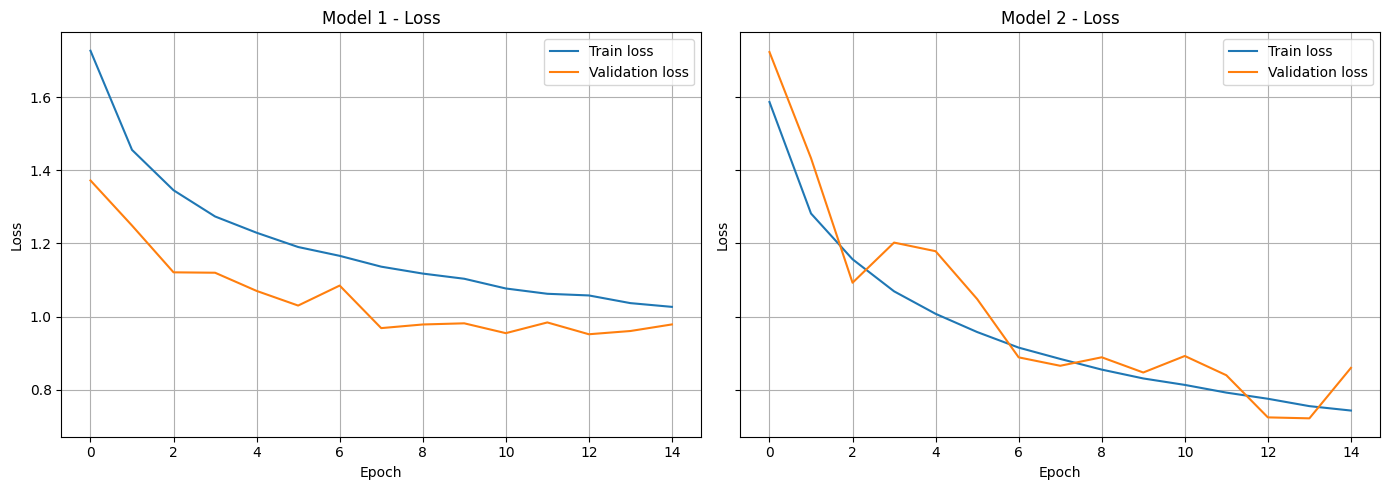

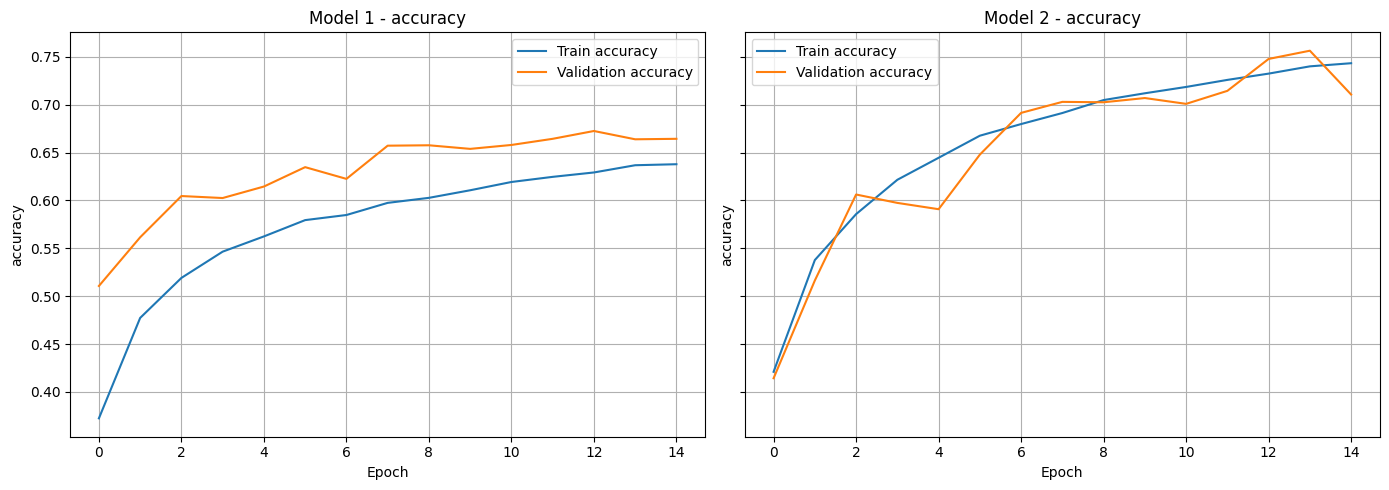

In [365]:
plot_losses_side_by_side(history_1, history_2)
plot_accuracies_side_by_side(history_1, history_2)

Ewaluacja na danych testowych

In [367]:
test_loss_1, test_acc_1 = model_1.evaluate(x_test, y_test, verbose=0)
test_loss_2, test_acc_2 = model_2.evaluate(x_test, y_test, verbose=0)

print("Model 1 - test accuracy:", test_acc_1)
print("Model 2 - test accuracy:", test_acc_2)

Model 1 - test accuracy: 0.6679166555404663
Model 2 - test accuracy: 0.7149166464805603


Porównanie modeli

In [372]:
results = pd.DataFrame({
    "Model": ["Model 1 - prostszy CNN", "Model 2 - głębszy CNN"],
    "Test loss": [test_loss_1, test_loss_2],
    "Test accuracy": [test_acc_1, test_acc_2]
})

results

,Model,Test loss,Test accuracy
0,Model 1 - prostszy CNN,0.979537,0.667917
1,Model 2 - głębszy CNN,0.873796,0.714917


Confusion Matrix

375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step


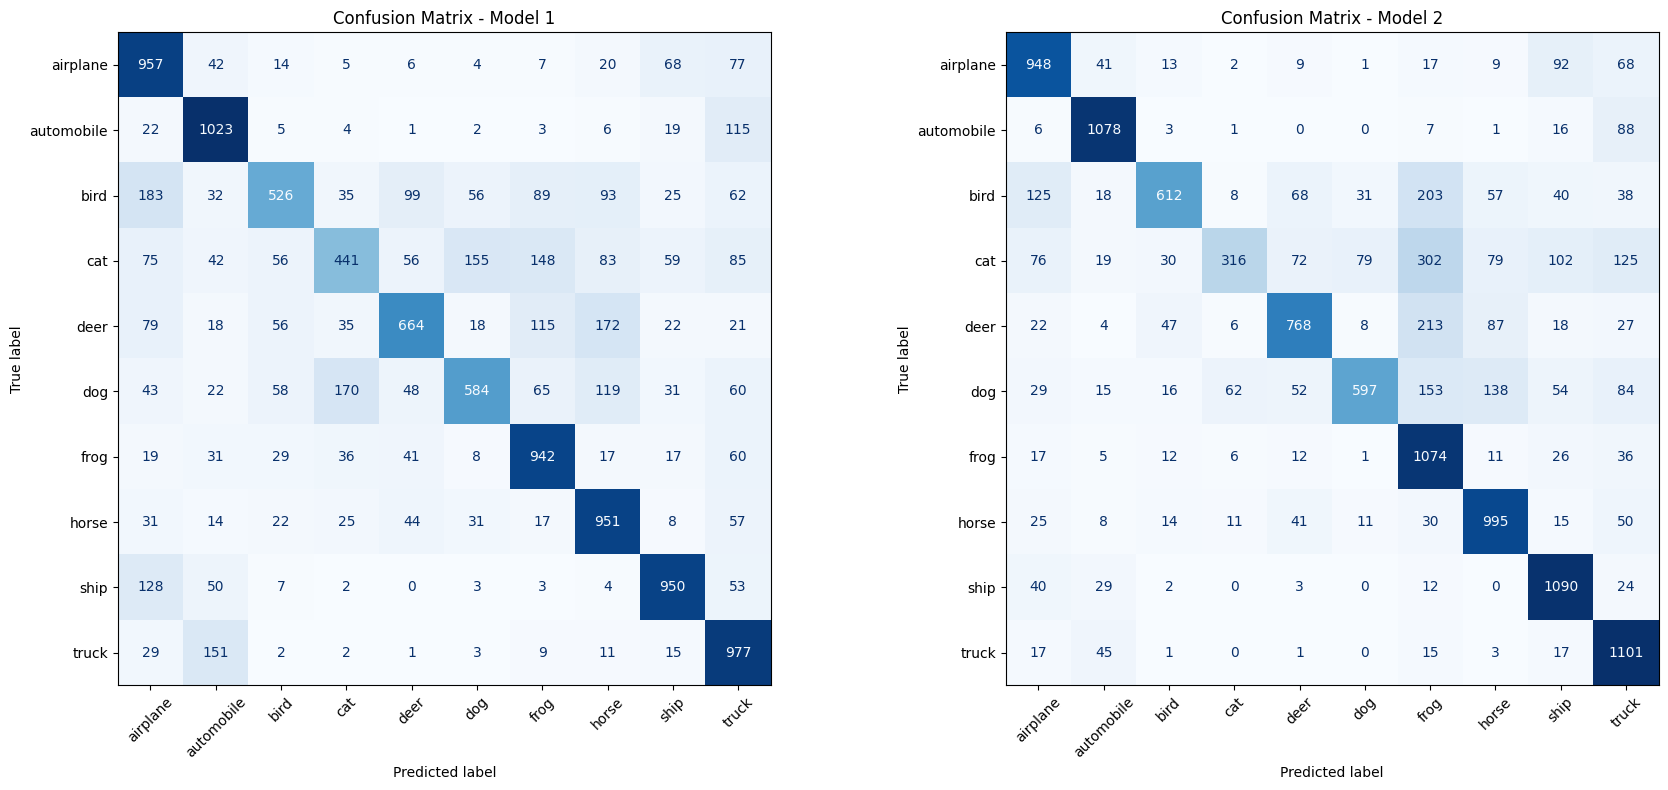

In [411]:
y_test_flat = y_test.ravel()

# Predykcje Model 1
y_pred_1 = model_1.predict(x_test)
y_pred_1_classes = np.argmax(y_pred_1, axis=1)

# Predykcje Model 2
y_pred_2 = model_2.predict(x_test)
y_pred_2_classes = np.argmax(y_pred_2, axis=1)

# Confusion matrix
cm_1 = confusion_matrix(y_test_flat, y_pred_1_classes)
cm_2 = confusion_matrix(y_test_flat, y_pred_2_classes)

# Rysowanie obok siebie
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

disp_1 = ConfusionMatrixDisplay(
    confusion_matrix=cm_1,
    display_labels=class_names
)

disp_1.plot(
    ax=axes[0],
    cmap="Blues",
    xticks_rotation=45,
    colorbar=False
)
axes[0].set_title("Confusion Matrix - Model 1")

disp_2 = ConfusionMatrixDisplay(
    confusion_matrix=cm_2,
    display_labels=class_names
)

disp_2.plot(
    ax=axes[1],
    cmap="Blues",
    xticks_rotation=45,
    colorbar=False
)
axes[1].set_title("Confusion Matrix - Model 2")

plt.tight_layout()
plt.show()

Wystąpienia klas w zbiorze treningowym

In [417]:
y_train_flat = y_train.ravel()

classes, counts = np.unique(y_train_flat, return_counts=True)

for class_id, count in zip(classes, counts):
    print(class_id, class_names[class_id], count)

0 airplane 3600
1 automobile 3600
2 bird 3600
3 cat 3600
4 deer 3600
5 dog 3600
6 frog 3600
7 horse 3600
8 ship 3600
9 truck 3600


Wybór najlepszego modelu

In [396]:
if test_acc_1 > test_acc_2:
    best_model = model_1
    best_predictions = y_pred_1_classes
    best_model_name = "Model 1"
else:
    best_model = model_2
    best_predictions = y_pred_2_classes
    best_model_name = "Model 2"

print("Najlepszy model:", best_model_name)

Najlepszy model: Model 2


Analiza błędnych klasyfikacji

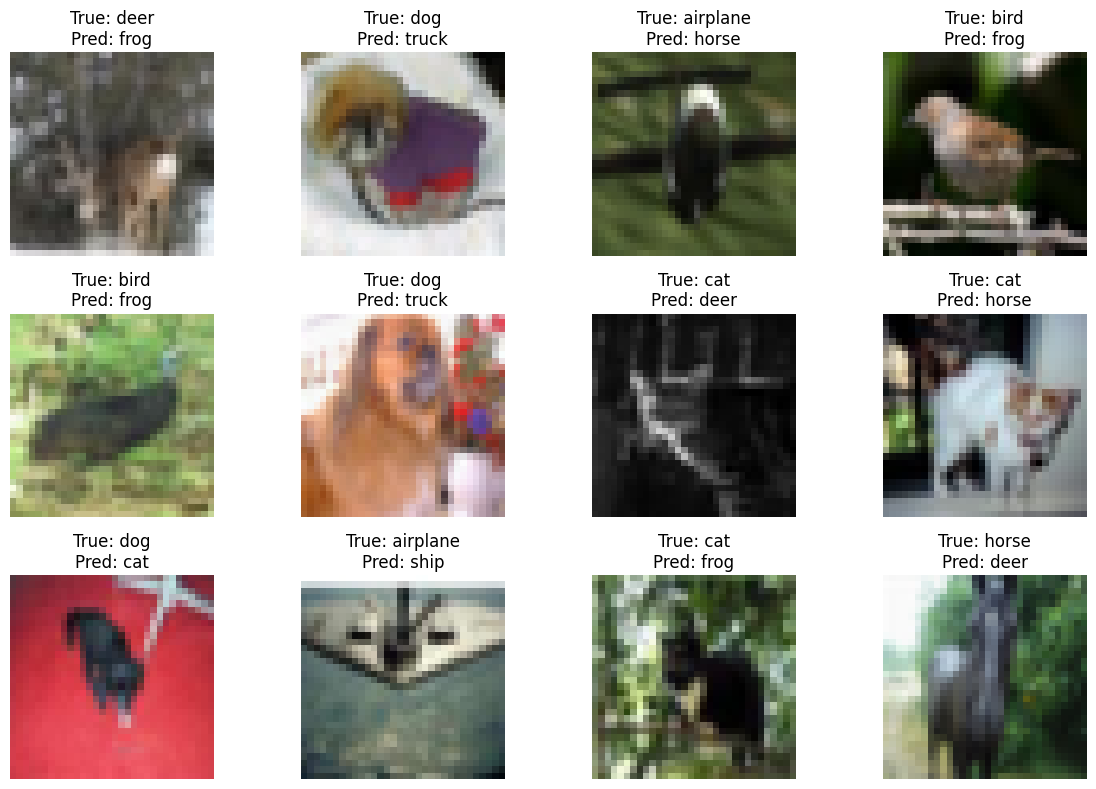

In [410]:
y_test_flat = y_test.ravel()
wrong_indexes = np.where(best_predictions != y_test_flat)[0]

plt.figure(figsize=(12, 8))

for i, idx in enumerate(wrong_indexes[:12]):
    plt.subplot(3, 4, i + 1)
    plt.imshow(x_test[idx])
    plt.title(
        f"True: {class_names[int(y_test_flat[idx])]}\nPred: {class_names[int(best_predictions[idx])]}"
    )
    plt.axis("off")

plt.tight_layout()
plt.show()

Wnioski

W projekcie wykorzystano zbiór CIFAR-10, który zawiera obrazy należące do 10 klas. Dane podzielono na zbiory treningowy, walidacyjny i testowy w proporcji 60/20/20. Przed trenowaniem zastosowano normalizację pikseli do zakresu 0–1 oraz prostą augmentację danych, czyli losowe odbicie poziome i niewielką rotację obrazu.

Przetestowano dwa modele CNN. Model 1 jest prostszy — zawiera dwie warstwy konwolucyjne, warstwę Flatten, warstwę gęstą oraz Dropout. Model 2 jest bardziej rozbudowany — ma więcej warstw konwolucyjnych, wykorzystuje BatchNormalization, Dropout oraz GlobalAveragePooling2D.

Macierz pomyłek pokazuje, które klasy model myli najczęściej. Najwięcej błędów pojawia się między podobnymi klasami, np. cat i dog, automobile i truck, deer i horse. Widoczne są też pojedyncze pomyłki między mniej podobnymi klasami, np. frog i bird, cat lub deer.

Na podstawie wykresów straty treningowej i walidacyjnej można ocenić sposób uczenia modeli. Jeżeli strata treningowa spada, a walidacyjna rośnie, oznacza to overfitting. Jeżeli obie straty są wysokie, może to świadczyć o underfittingu.

Lepszym modelem jest Model 2, ponieważ osiąga wyższą accuracy na zbiorze testowym. Jednocześnie różnica między wynikami treningowymi i walidacyjnymi jest większa niż w Modelu 1, co może wskazywać na pewien overfitting. Mimo tego Model 2 wypada najlepiej, ponieważ daje najwyższą skuteczność klasyfikacji na danych testowych.